In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
mean_squared_error,
mean_absolute_error,
r2_score
)
from scipy import stats
print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn
import scipy
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", sns.__version__)
print("Scikit-learn:", sklearn.__version__)
print("SciPy:", scipy.__version__)


NumPy: 2.1.3
Pandas: 2.2.3
Matplotlib: 3.10.0
Seaborn: 0.13.2
Scikit-learn: 1.6.1
SciPy: 1.15.3


In [4]:
# Part 1: Setup and Import Libraries

# ===============================
# Import Required Libraries
# ===============================
# Numerical computing
import numpy as np
# Data manipulation
import pandas as pd
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning utilities
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
# Regression algorithms
from sklearn.linear_model import LinearRegression, Ridge, Lasso
# Model evaluation metrics
from sklearn.metrics import (
mean_squared_error,
mean_absolute_error,
r2_score
)
# Statistical analysis
from scipy import stats
# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# To improve the apperance of the visualization
# Set visualization style
plt.style.use("seaborn-v0_8-darkgrid")
# Set default color palette
sns.set_palette("husl")
print ("liberary setup successfully")

liberary setup successfully


In [5]:
# ============================================
# Part 2: Load and Explore the Dataset
# ============================================

try:
    # California Housing Dataset URL
    url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"

    # Load dataset from URL
    df = pd.read_csv(url)

    print("Dataset loaded successfully from URL!")

except Exception as e:

    print("URL download failed.")
    print("Error:", e)
    print("Generating synthetic dataset...")

    # Set random seed
    np.random.seed(42)

    # Number of samples
    n_samples = 5000

    # Create synthetic dataset
    df = pd.DataFrame({
        "longitude": np.random.uniform(-124.5, -114.5, n_samples),
        "latitude": np.random.uniform(32.5, 42.0, n_samples),
        "housing_median_age": np.random.randint(1, 52, n_samples),
        "total_rooms": np.random.normal(2000, 1000, n_samples).astype(int),
        "total_bedrooms": np.random.normal(500, 250, n_samples).astype(int),
        "population": np.random.normal(1200, 800, n_samples).astype(int),
        "households": np.random.normal(450, 250, n_samples).astype(int),
        "median_income": np.random.uniform(0.5, 15, n_samples),
        "ocean_proximity": np.random.choice(
            [
                "NEAR BAY",
                "<1H OCEAN",
                "INLAND",
                "NEAR OCEAN",
                "ISLAND"
            ],
            size=n_samples,
            p=[0.30, 0.30, 0.30, 0.09, 0.01]
        )
    })

    # Create median house value
    df["median_house_value"] = (
        df["median_income"] * 40000 +
        df["housing_median_age"] * 1000 +
        df["total_rooms"] * 20 +
        np.random.normal(0, 30000, n_samples)
    ).astype(int)

    # Limit prices
    df["median_house_value"] = df["median_house_value"].clip(
        lower=50000,
        upper=500001
    )

    print("Synthetic dataset created successfully!")


# ============================================
# Display first few rows
# ============================================

print(df.head())


# ============================================
# Check Dataset Information
# ============================================

print("\nDataset Information")
print("-" * 50)
df.info()


# ============================================
# Check Missing Values
# ============================================

print("\nMissing Values")
print("-" * 50)
print(df.isnull().sum())

Dataset loaded successfully from URL!
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

Dataset Information
----------------

In [9]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (20640, 10)


In [10]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [6]:
print("First Five Rows:")
df.head()


First Five Rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [22]:
if df.isnull().sum().sum() > 0:
    print("Removing rows with missing values...")
    df = df.dropna()
    print(f"New Dataset Shape: {df.shape}")

Removing rows with missing values...
New Dataset Shape: (20433, 10)


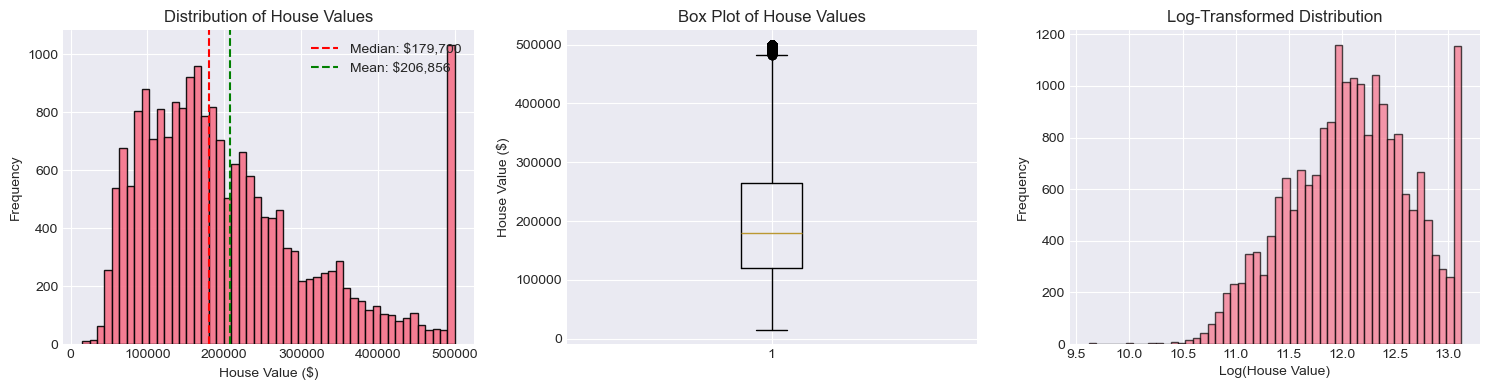

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# --------------------------
# Histogram
# --------------------------
axes[0].hist(
df["median_house_value"],
bins=50,
edgecolor="black",
alpha=0.9
)
axes[0].set_title("Distribution of House Values")
axes[0].set_xlabel("House Value ($)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(
df["median_house_value"].median(),
color="red",
linestyle="--",
label=f"Median: ${df['median_house_value'].median():,.0f}"
)
axes[0].axvline(
df["median_house_value"].mean(),
color="green",
linestyle="--",
label=f"Mean: ${df['median_house_value'].mean():,.0f}"
)
axes[0].legend()
# --------------------------
# Box Plot
# --------------------------

axes[1].boxplot(df["median_house_value"])
axes[1].set_title("Box Plot of House Values")
axes[1].set_ylabel("House Value ($)")
# --------------------------
# Log Transformation
# --------------------------
axes[2].hist(
np.log1p(df["median_house_value"]),
bins=50,
edgecolor="black",
alpha=0.7
)

axes[2].set_title("Log-Transformed Distribution")
axes[2].set_xlabel("Log(House Value)")
axes[2].set_ylabel("Frequency")
plt.tight_layout()
plt.show()


In [9]:
numeric_columns = df.select_dtypes(include=[np.number]).columns
correlations = (
df[numeric_columns]
.corr()["median_house_value"]
.sort_values(ascending=False)
)
print("Top Correlations with House Price")
print(correlations)


Top Correlations with House Price
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


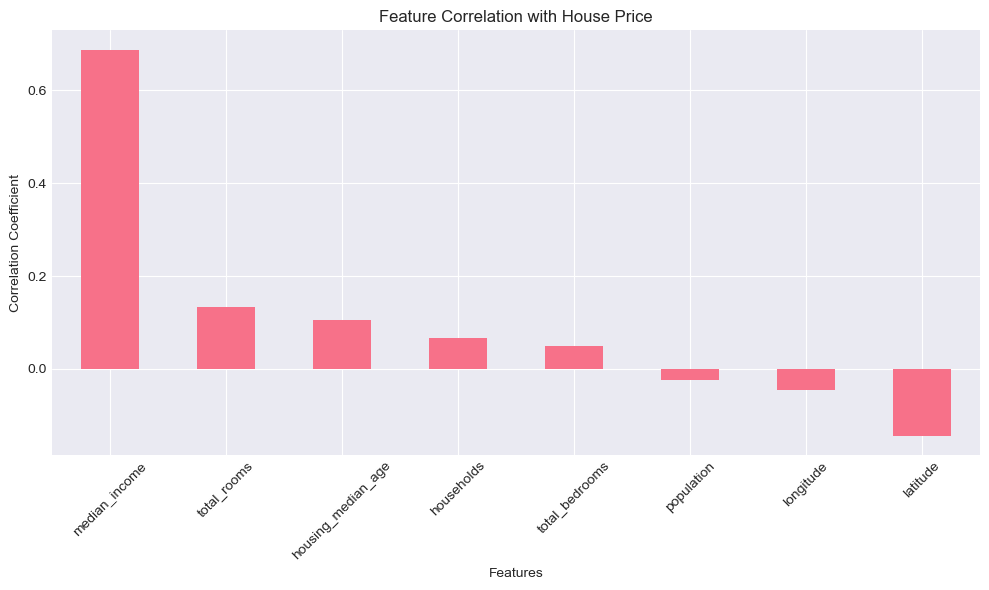

In [10]:
plt.figure(figsize=(10, 6))
correlations.drop("median_house_value").plot(kind="bar")
plt.title("Feature Correlation with House Price")
plt.xlabel("Features")
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

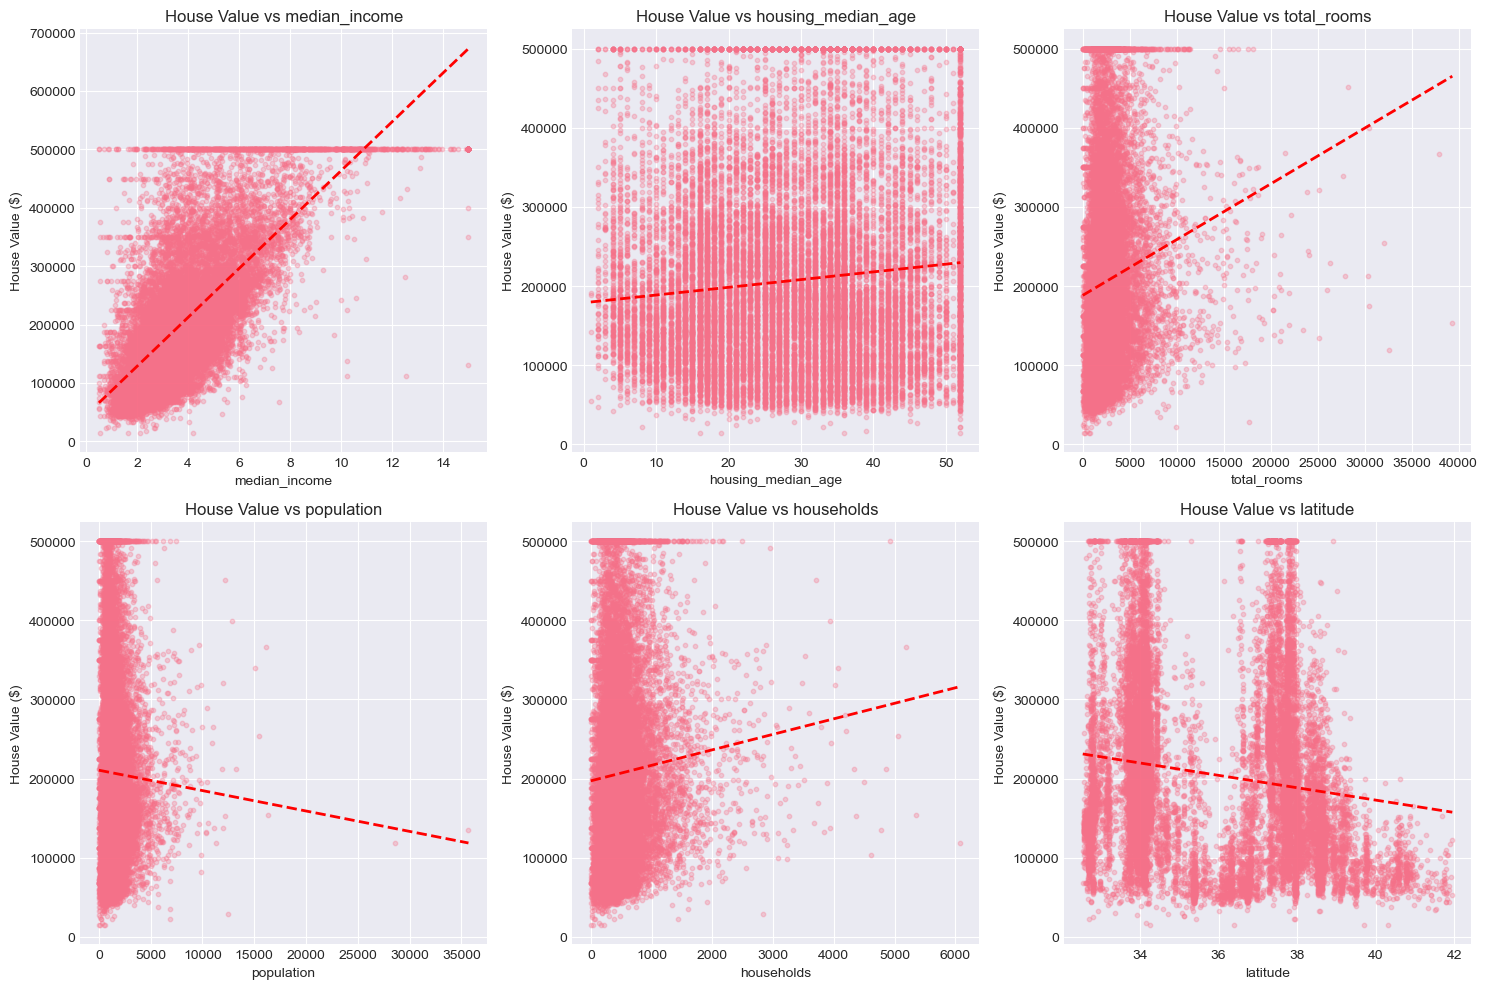

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = [
"median_income",
"housing_median_age",
"total_rooms",
"population",
"households",
"latitude"
]
for index, feature in enumerate(features):
    row = index // 3
    column = index % 3
    axes[row, column].scatter(
    df[feature],
    df["median_house_value"],
    alpha=0.3,
    s=10
    )
    axes[row, column].set_title(f"House Value vs {feature}")
    axes[row, column].set_xlabel(feature)
    axes[row, column].set_ylabel("House Value ($)")
    # Add linear trend line
    z = np.polyfit(df[feature], df["median_house_value"], 1)
    p = np.poly1d(z)
    axes[row, column].plot(
    df[feature].sort_values(),
    p(df[feature].sort_values()),
    "r--",
    linewidth=2
    )
plt.tight_layout()
plt.show()